11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8725 - loss: 0.5025 - val_accuracy: 0.9145 - val_loss: 0.3155
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9123 - loss: 0.3174 - val_accuracy: 0.9215 - val_loss: 0.2880
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9180 - loss: 0.2934 - val_accuracy: 0.9248 - val_loss: 0.2763
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9212 - loss: 0.2815 - val_accuracy: 0.9222 - val_loss: 0.2761
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9233 - loss: 0.2733 - val_accuracy: 0.9256 - val_loss: 0.2693
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9256 - loss: 0.2678 - val_accuracy: 0.9263 - val_loss: 0.2677
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9264 - loss: 0.2641 - val_accuracy: 0.9276 - val_loss: 0.2662
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━

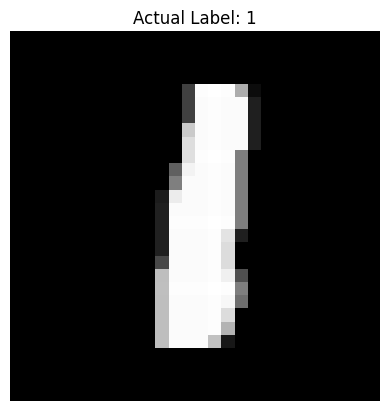


➜ 모델이 예측한 레이블: 1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras.utils import to_categorical

# MNIST 데이터셋 불러오기
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 데이터 정규화
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 레이블 데이터를 원-핫 인코딩으로 변환
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 소프트맥스 회귀 모델 구축
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),    # 2차원(28x28)을 1차원(784)으로 평탄화
    Dense(10, activation='softmax')
])

# 모델 컴파일
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 학습
model.fit(x_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# 모델 평가
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f'\n모델 정확도: {test_acc*100:.2f} %\n')

# 테스트 이미지 판독 예제
print('\n▶ 임의의 이미지 판독 테스트\n')
sample_index = np.random.randint(0, x_test.shape[0])
sample_image = x_test[sample_index]

plt.imshow(sample_image, cmap='gray')
plt.title(f'Actual Label: {y_test[sample_index]}')
plt.axis('off')
plt.show()

# 입력 형식 맞추기: (1, 28, 28)
sample_input = sample_image.reshape(1, 28, 28).astype('float32')
prediction = model.predict(sample_input, verbose=0)
predicted_label = np.argmax(prediction)
print('\n➜ 모델이 예측한 레이블:', predicted_label)